In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from utils import compute_sheaf_loss



In [2]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [3]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


#X_1 = StandardScaler().fit_transform(X1)
#X_1 = X_1  # -> (d, N)
#X_2 = StandardScaler().fit_transform(X2)
#X_2 = X_2  # -> (d, N)
#X_3 = StandardScaler().fit_transform(X3)
#X_3 = X_3  # -> (d, N)

norm = np.linalg.norm(X1, axis=1, keepdims=True)   # shape (1, n)
X_1 = X1 / norm
norm = np.linalg.norm(X2, axis=1, keepdims=True)   # shape (1, n)
X_2 = X2 / norm
norm = np.linalg.norm(X3, axis=1, keepdims=True)   # shape (1, n)
X_3 = X3 / norm


d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}
""" 
X_dict = create_correlated_datasets(
    X_base=X_1,   # your original dataset
    n_users=3,
    n_total=d,
    n_shared=50   # 40% shared
)
 """

d: 60000, N: 128, K: 180000, k_sparsity: 6000
Data shape: (60000, 128) (60000, 128) (60000, 128)


' \nX_dict = create_correlated_datasets(\n    X_base=X_1,   # your original dataset\n    n_users=3,\n    n_total=d,\n    n_shared=50   # 40% shared\n)\n '

In [ ]:
torch.norm(X_dict[0], 2, dim=0)

torch.Size([60000])

In [4]:
from utils import SingleUserSCADict

num_users = 3


device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 2.0)
k_sparsity = int(d * 0.1)

model = SingleUserSCADict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=10.0,
    alpha=0.9,
    gamma=0.999,
    beta=0,
    device=device
)

# =========================================================
# TRAIN
# =========================================================
D, S, losses = model.fit(X_dict[0], outer_iters=200)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for _, (i, X_i) in zip(range(1), X_dict.items()):
    X_i = X_i.to(device)
    S_i = S
    print(model.D.shape, X_i.shape, S_i.shape)
    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")


128 60000
iter 1: loss=212.494568
0.8991 0.999 0
iter 2: loss=137.829376
0.8982009 0.999 0
iter 3: loss=78.513618
0.8973026990999999 0.999 0
iter 4: loss=157.064972
0.8964053964008999 0.999 0
iter 5: loss=106.993088
0.895508991004499 0.999 0
iter 6: loss=197.543167
0.8946134820134944 0.999 0
iter 7: loss=161.756073
0.893718868531481 0.999 0
iter 8: loss=53.608181
0.8928251496629495 0.999 0
iter 9: loss=206.989578
0.8919323245132865 0.999 0
iter 10: loss=59.389473
0.8910403921887733 0.999 0
iter 11: loss=233.989594
0.8901493517965845 0.999 0
iter 12: loss=82.909416
0.889259202444788 0.999 0
iter 13: loss=120.648445
0.8883699432423432 0.999 0
iter 14: loss=52.908016
0.8874815732991008 0.999 0
iter 15: loss=61.862988
0.8865940917258017 0.999 0
iter 16: loss=31.947054
0.885707497634076 0.999 0
iter 17: loss=42.142899
0.8848217901364419 0.999 0
iter 18: loss=26.977757
0.8839369683463054 0.999 0
iter 19: loss=34.438671
0.8830530313779591 0.999 0
iter 20: loss=26.382132
0.8821699783465812 0.9

In [5]:
k_sparsity

12

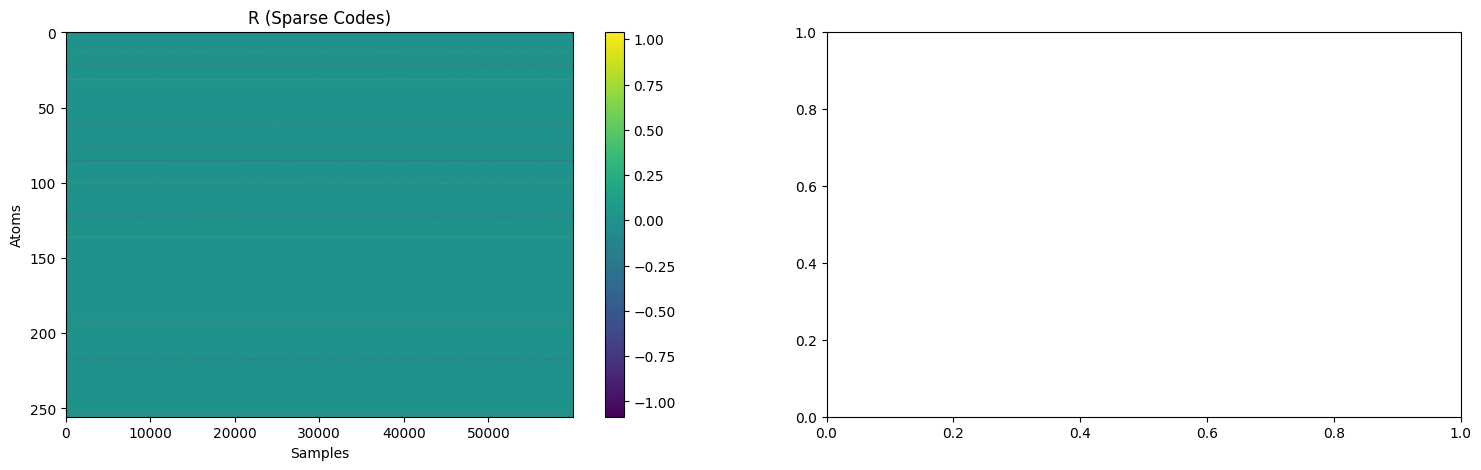

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S.cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

In [7]:
X_np = X_dict[0].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="SCA"
)


===== SCA =====
Avg error: 7.3208
Std error: 1.8487
Avg sparsity: 12.00
Sparsity ratio: 0.0469


In [8]:
np.mean(np.linalg.norm(D_np @ R_np - X_np, axis=0) / np.linalg.norm(X_np, axis=0)) * 100

np.float32(7.3208256)

In [9]:
print(X_np.shape)
print(np.linalg.norm(X_np, axis=0))

(128, 60000)
[1.         1.         1.         ... 0.99999994 0.99999994 0.99999994]


In [33]:
from utils import MultiUserSCADict
# =========================================================
# SETUP
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# MODEL
# =========================================================
d, N = X_dict[0].shape
print(d, N)
K = int(d * 2.0)
k_sparsity = int(d * 0.1)


model = MultiUserSCADict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    edges=edges,          # list of (u,v)
    mu=0,
    rho=5.0,
    alpha=0.9,
    gamma=0.999,
    beta=0,
    num_fp_iters=10,
    tol=1e-5,
    gamma_D=1e-1*2,
    device=device
)


# =========================================================
# TRAIN
# =========================================================
D, S_dict, losses = model.fit(X_dict, outer_iters=200)

128 60000
D fixed-point converged at iter 1, diff=0.000000e+00
iter 1: loss=108721.328125
D fixed-point converged at iter 1, diff=0.000000e+00
iter 2: loss=54326.187500
D fixed-point converged at iter 1, diff=0.000000e+00
iter 3: loss=437368.562500
D fixed-point converged at iter 1, diff=0.000000e+00
iter 4: loss=395907.000000
D fixed-point converged at iter 1, diff=0.000000e+00
iter 5: loss=172413.437500
D fixed-point converged at iter 1, diff=0.000000e+00
iter 6: loss=51799.351562
D fixed-point converged at iter 1, diff=0.000000e+00
iter 7: loss=118664.453125
D fixed-point converged at iter 1, diff=0.000000e+00
iter 8: loss=301441.000000
D fixed-point converged at iter 1, diff=0.000000e+00
iter 9: loss=327464.875000
D fixed-point converged at iter 1, diff=0.000000e+00
iter 10: loss=164671.656250
D fixed-point converged at iter 1, diff=0.000000e+00
iter 11: loss=83231.625000
D fixed-point converged at iter 1, diff=0.000000e+00
iter 12: loss=191553.125000
D fixed-point converged at ite

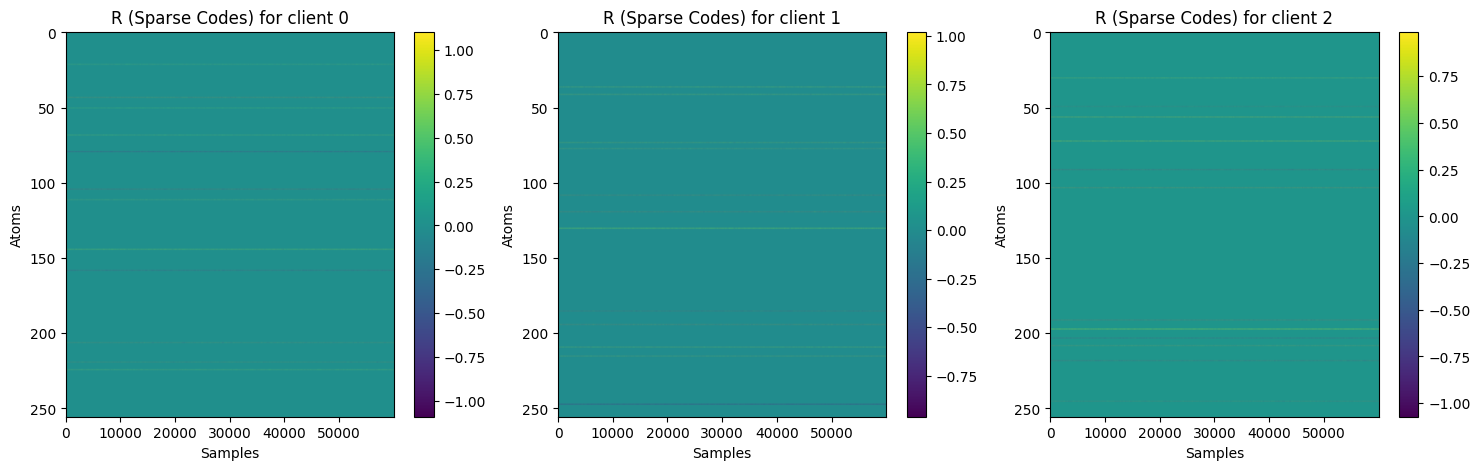

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

S0 = S_dict[0].detach().cpu().numpy()
S1 = S_dict[1].detach().cpu().numpy()
S2 = S_dict[2].detach().cpu().numpy()

# Sparse codes
im0 = axes[0].imshow(S0, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes) for client 0")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
im1 = axes[1].imshow(S1, aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes) for client 1")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
im2 = axes[2].imshow(S2, aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes) for client 2")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")

plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])
plt.colorbar(im2, ax=axes[2])

In [35]:
for i in X_dict:
    X_np = X_dict[i].detach().cpu().numpy()
    D_np = D.detach().cpu().numpy()
    R_np = S_dict[i].detach().cpu().numpy()

    errors, sparsity = compute_metrics(
        X_np,
        D_np,
        R_np,
        name=f"SCA for Client {i}"
    )

compute_sheaf_loss(model, S_dict, X_dict, device, verbose=True)


===== SCA for Client 0 =====
Avg error: 7.8611
Std error: 1.9533
Avg sparsity: 12.00
Sparsity ratio: 0.0469

===== SCA for Client 1 =====
Avg error: 8.5631
Std error: 2.0747
Avg sparsity: 12.00
Sparsity ratio: 0.0469

===== SCA for Client 2 =====
Avg error: 7.2966
Std error: 2.0714
Avg sparsity: 12.00
Sparsity ratio: 0.0469
Edge (0, 1): error = 184.0110%
Edge (1, 2): error = 183.5610%
Edge (0, 2): error = 184.5316%
Total Sheaf loss: 319024.9688


(tensor(319024.9688, device='cuda:0'),
 {(0, 1): 184.01095581054688,
  (1, 2): 183.56101989746094,
  (0, 2): 184.53158569335938})

In [36]:
from utils import MultiUserSheafSCADict
# =========================================================
# SETUP
# =========================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# MODEL
# =========================================================
d, N = X_dict[0].shape
print(d, N)
K = int(d * 2.0)
k_sparsity = int(d * 0.1)


model = MultiUserSheafSCADict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    edges=edges,          # list of (u,v)
    mu=1e-2,
    rho=2.0,
    alpha=0.9,
    gamma=0.999,
    beta=0.0,
    num_fp_iters=20,
    tol=1e-5,
    device=device
)


# =========================================================
# TRAIN
# =========================================================
D, S_dict, losses = model.fit(X_dict, outer_iters=200)

128 60000
D fixed-point converged at iter 0, diff=0.000000e+00
iter 1: loss=71723.554688
iter 2: loss=25998.072266
iter 3: loss=7090.692383
iter 4: loss=11436.029297
iter 5: loss=13650.124023
iter 6: loss=52058.714844
iter 7: loss=80448.117188
iter 8: loss=61258.656250
iter 9: loss=39854.023438
iter 10: loss=17298.263672
iter 11: loss=23131.501953
iter 12: loss=12230.589844
iter 13: loss=14847.102539
iter 14: loss=9636.299805
iter 15: loss=9425.112305
iter 16: loss=7109.578613
iter 17: loss=6149.795410
iter 18: loss=5905.087891
iter 19: loss=5378.752930
D fixed-point converged at iter 11, diff=9.902138e-06
iter 20: loss=5426.364258
D fixed-point converged at iter 9, diff=9.988647e-06
iter 21: loss=5191.660156
D fixed-point converged at iter 7, diff=9.366347e-06
iter 22: loss=5274.867188
D fixed-point converged at iter 7, diff=9.755947e-06
iter 23: loss=5078.543945
D fixed-point converged at iter 6, diff=9.451650e-06
iter 24: loss=5032.876953
D fixed-point converged at iter 6, diff=9.01

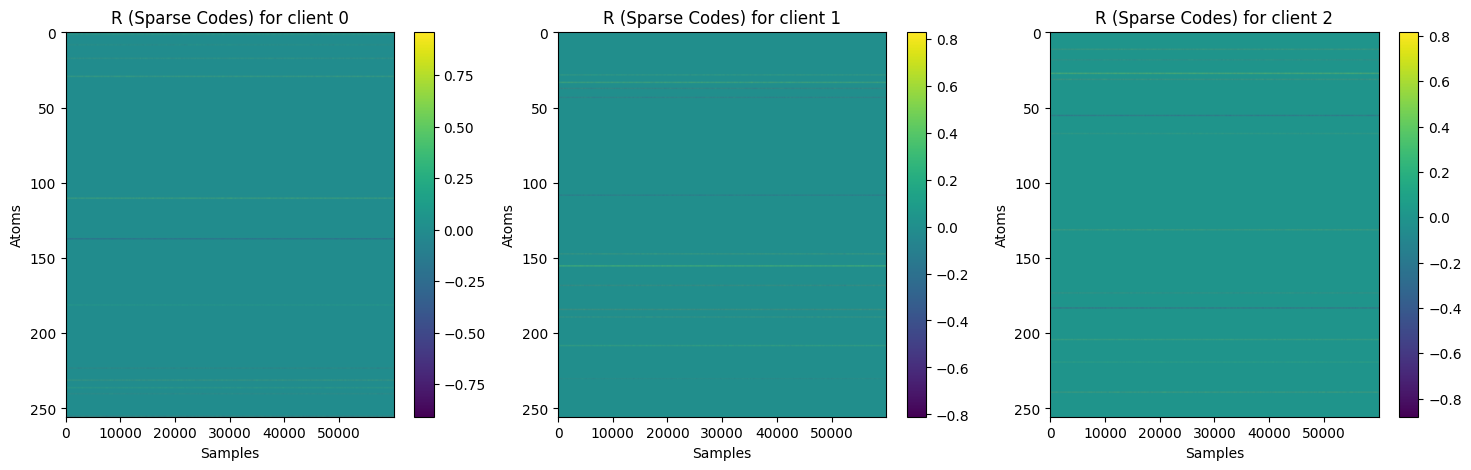

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

S0 = S_dict[0].detach().cpu().numpy()
S1 = S_dict[1].detach().cpu().numpy()
S2 = S_dict[2].detach().cpu().numpy()

# Sparse codes
im0 = axes[0].imshow(S0, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes) for client 0")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
im1 = axes[1].imshow(S1, aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes) for client 1")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
im2 = axes[2].imshow(S2, aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes) for client 2")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")

plt.colorbar(im0, ax=axes[0])
plt.colorbar(im1, ax=axes[1])
plt.colorbar(im2, ax=axes[2])

In [38]:
for i in X_dict:
    X_np = X_dict[i].detach().cpu().numpy()
    D_np = D.detach().cpu().numpy()
    R_np = S_dict[i].detach().cpu().numpy()

    errors, sparsity = compute_metrics(
        X_np,
        D_np,
        R_np,
        name=f"SCA for Client {i}"
    )

compute_sheaf_loss(model, S_dict, X_dict, device, verbose=True)


===== SCA for Client 0 =====
Avg error: 8.2528
Std error: 1.6523
Avg sparsity: 12.00
Sparsity ratio: 0.0469

===== SCA for Client 1 =====
Avg error: 8.0945
Std error: 1.5470
Avg sparsity: 12.00
Sparsity ratio: 0.0469

===== SCA for Client 2 =====
Avg error: 6.8298
Std error: 1.1953
Avg sparsity: 12.00
Sparsity ratio: 0.0469
Edge (0, 1): error = 175.5552%
Edge (1, 2): error = 175.2986%
Edge (0, 2): error = 176.0866%
Total Sheaf loss: 293112.6250


(tensor(293112.6250, device='cuda:0'),
 {(0, 1): 175.55517578125,
  (1, 2): 175.29856872558594,
  (0, 2): 176.08660888671875})